# Deteksi Phishing — Model FULL (URL + fitur konten STABIL) — XGBoost + PhiUSIIL

Model ini = **jalur FULL** dari arsitektur adaptif backend: *scrape HTML dulu → kalau bisa diakses pakai model ini; kalau gagal → fallback ke model URL-only* (`skripsi.ipynb`).

**Anti-leakage & anti-skew:**
- Buang fitur **leakage/target-encoding**: `URLSimilarityIndex`, `TLDLegitimateProb`, `URLCharProb`.
- Buang fitur **HTML rapuh** (`NoOfCSS`, `LineOfCode`, `NoOfImage`, `NoOfJS`, dll) yang nilainya beda jauh antara crawler PhiUSIIL vs scrape live → **sumber utama skew** (dulu bikin google.com salah).
- **Pertahankan fitur URL** (deterministik) + **fitur HTML stabil/biner** (`HasTitle`, `HasFavicon`, `HasPasswordField`, `HasExternalFormSubmit`, `Robots`, `IsResponsive`, `HasCopyrightInfo`, dst).
- **RFE (12 fitur)**, **tuning GroupKFold**, **threshold**, **permutation test**, **SHAP**, split **per-domain**.

> Struktur analisis (EDA, keseimbangan kelas, permutation test, feature importance) dibuat **konsisten** dengan `skripsi.ipynb` (model URL-only) agar mudah dibandingkan di skripsi. Bedanya: di sini fitur = URL + HTML stabil, dan seleksi pakai **RFE 12** (bukan RFECV).

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, auc, make_scorer,
)

# Hanya untuk membuat GROUP (domain) saat split -> bukan fitur model.
from url_features import extract_registered_domain

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TEST_SIZE = 0.2
f1_phish = make_scorer(f1_score, pos_label=0)   # fokus deteksi phishing (label 0)
print('Setup OK.')

Setup OK.


In [2]:
# 1. LOAD DATASET + BANGUN FITUR (URL + HTML STABIL)
filename = 'PhiUSIIL_Phishing_URL_Dataset.csv'
df = pd.read_csv(filename)
print(f'Data: {df.shape[0]:,} baris, {df.shape[1]} kolom')
assert {'URL', 'label'}.issubset(df.columns)
df = df.dropna(subset=['label']).drop_duplicates(subset=['URL']).reset_index(drop=True)
print(f'Setelah dedupe: {len(df):,} baris')

# --- Kolom yang WAJIB dibuang ---
LEAKAGE_COLS = ['URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb']   # target-encoding -> leakage
ID_COLS      = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']                # identitas/teks

# Fitur HTML RAPUH (sangat tergantung cara crawl/render) -> dibuang supaya jalur HTML
# di backend (scrape live) tidak meleset karena train-serving skew.
FRAGILE_HTML_COLS = [
    'NoOfCSS', 'NoOfJS', 'NoOfImage', 'LineOfCode', 'LargestLineLength',
    'NoOfSelfRef', 'NoOfExternalRef', 'NoOfEmptyRef', 'NoOfPopup',
    'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasSocialNet', ''
]
# Fitur HTML yang DIPERTAHANKAN = sinyal stabil/biner yang konsisten saat di-scrape live:
#   HasTitle, DomainTitleMatchScore, URLTitleMatchScore, HasFavicon, Robots, IsResponsive,
#   HasDescription, NoOfiFrame, HasExternalFormSubmit, HasSocialNet, HasSubmitButton,
#   HasHiddenFields, HasPasswordField, Bank, Pay, Crypto, HasCopyrightInfo
#   (+ SEMUA fitur URL yang memang deterministik)

drop_cols = [c for c in (LEAKAGE_COLS + ID_COLS + FRAGILE_HTML_COLS + ['label']) if c in df.columns]
print(f'Dibuang: leakage={LEAKAGE_COLS}')
print(f'         identitas={ID_COLS}')
print(f'         HTML rapuh={FRAGILE_HTML_COLS}')

# Group untuk split per-domain (dari URL, bukan fitur model)
groups = df['URL'].apply(extract_registered_domain).values

X = df.drop(columns=drop_cols).select_dtypes(include=[np.number]).fillna(0)
y = df['label'].astype(int).values
FEATURES = list(X.columns)

for c in LEAKAGE_COLS:
    assert c not in X.columns, f'{c} masih ada!'
print(f'\nJumlah fitur dipakai: {len(FEATURES)} (URL + HTML stabil)')
print(FEATURES)

Data: 235,795 baris, 56 kolom
Setelah dedupe: 235,370 baris
Dibuang: leakage=['URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb']
         identitas=['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
         HTML rapuh=['NoOfCSS', 'NoOfJS', 'NoOfImage', 'LineOfCode', 'LargestLineLength', 'NoOfSelfRef', 'NoOfExternalRef', 'NoOfEmptyRef', 'NoOfPopup', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasSocialNet', '']

Jumlah fitur dipakai: 35 (URL + HTML stabil)
['URLLength', 'DomainLength', 'IsDomainIP', 'CharContinuationRate', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'HasDescription', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSubmitButton', 'HasH

Distribusi kelas:
kelas
Legitimate    134850
Phishing      100520
Name: count, dtype: int64

Top 15 korelasi |fitur vs label|:
HasCopyrightInfo         0.743
HasDescription           0.690
IsHTTPS                  0.610
DomainTitleMatchScore    0.584
HasSubmitButton          0.579
IsResponsive             0.549
URLTitleMatchScore       0.539
SpacialCharRatioInURL    0.533
HasHiddenFields          0.508
HasFavicon               0.494
CharContinuationRate     0.467
HasTitle                 0.460
DegitRatioInURL          0.432
Robots                   0.392
LetterRatioInURL         0.367
Name: label, dtype: float64

[OK] korelasi tertinggi 0.743 (<0.95) -> tidak ada leakage fitur tunggal.


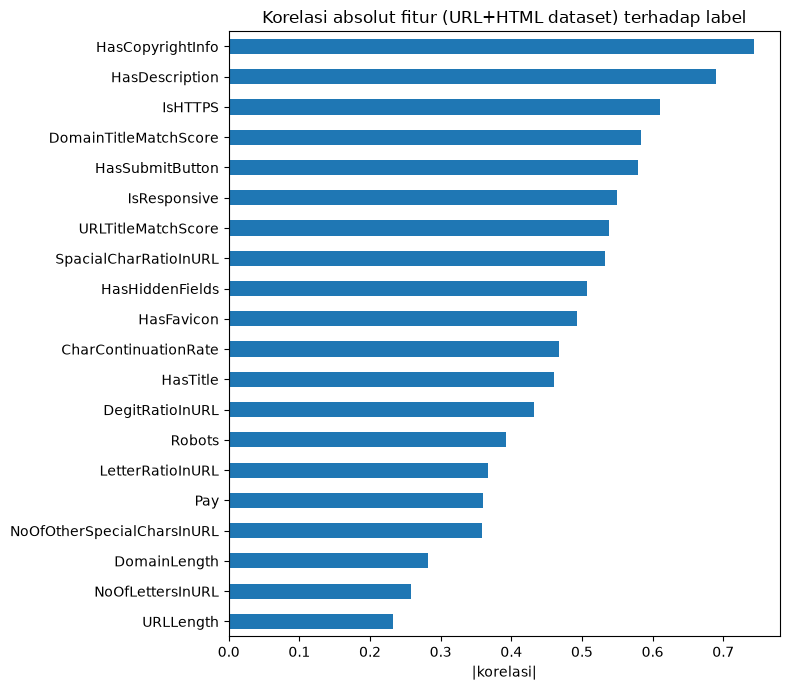

In [3]:
# 2. EDA + CEK LEAKAGE (korelasi |fitur vs label|)
eda = X.copy(); eda['kelas'] = np.where(y == 0, 'Phishing', 'Legitimate')
print('Distribusi kelas:')
print(eda['kelas'].value_counts())

corr = X.assign(label=y).corr(numeric_only=True)['label'].drop('label').abs().sort_values(ascending=False)
print('\nTop 15 korelasi |fitur vs label|:')
print(corr.head(15).round(3))
if corr.max() > 0.95:
    print(f'\n[!] Fitur "{corr.index[0]}" korelasi {corr.max():.3f} ~ kemungkinan leakage. Pertimbangkan buang.')
else:
    print(f'\n[OK] korelasi tertinggi {corr.max():.3f} (<0.95) -> tidak ada leakage fitur tunggal.')

plt.figure(figsize=(8, 7))
corr.head(20).plot(kind='barh'); plt.gca().invert_yaxis()
plt.title('Korelasi absolut fitur (URL+HTML dataset) terhadap label')
plt.xlabel('|korelasi|'); plt.tight_layout(); plt.show()

Ringkasan dataset:
  Baris=235,370 | Fitur=35 | Missing=0 | Duplikat fitur=108,254


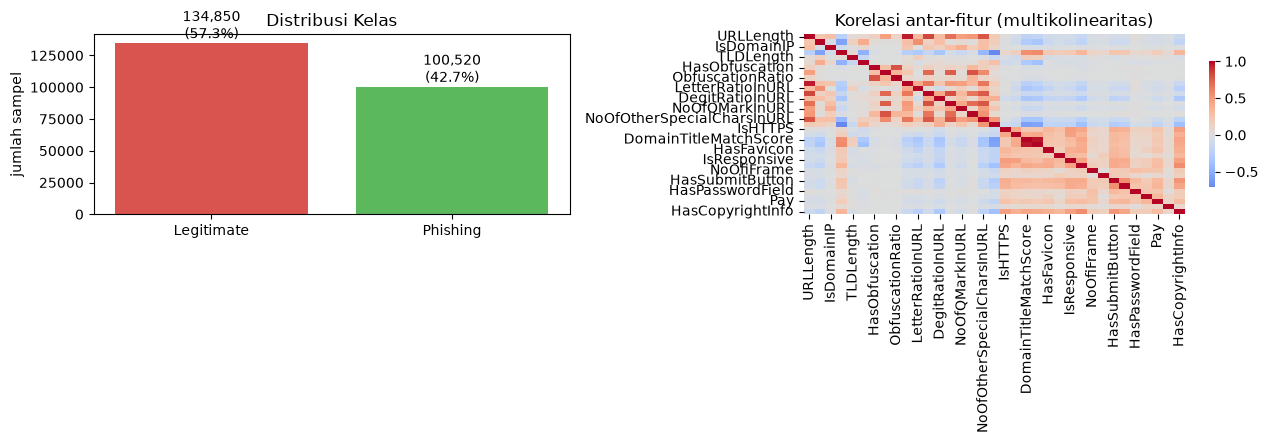


Statistik deskriptif fitur:
                             mean    std   min     50%      max
URLLength                   34.55  41.33  13.0   27.00  6097.00
DomainLength                21.46   9.13   4.0   20.00   110.00
IsDomainIP                   0.00   0.05   0.0    0.00     1.00
CharContinuationRate         0.85   0.22   0.0    1.00     1.00
TLDLength                    2.76   0.60   2.0    3.00    13.00
NoOfSubDomain                1.16   0.60   0.0    1.00    10.00
HasObfuscation               0.00   0.05   0.0    0.00     1.00
NoOfObfuscatedChar           0.02   1.88   0.0    0.00   447.00
ObfuscationRatio             0.00   0.00   0.0    0.00     0.35
NoOfLettersInURL            19.41  29.10   0.0   14.00  5191.00
LetterRatioInURL             0.52   0.12   0.0    0.52     0.93
NoOfDegitsInURL              1.88  11.89   0.0    0.00  2011.00
DegitRatioInURL              0.03   0.07   0.0    0.00     0.68
NoOfEqualsInURL              0.06   0.94   0.0    0.00   176.00
NoOfQMarkIn

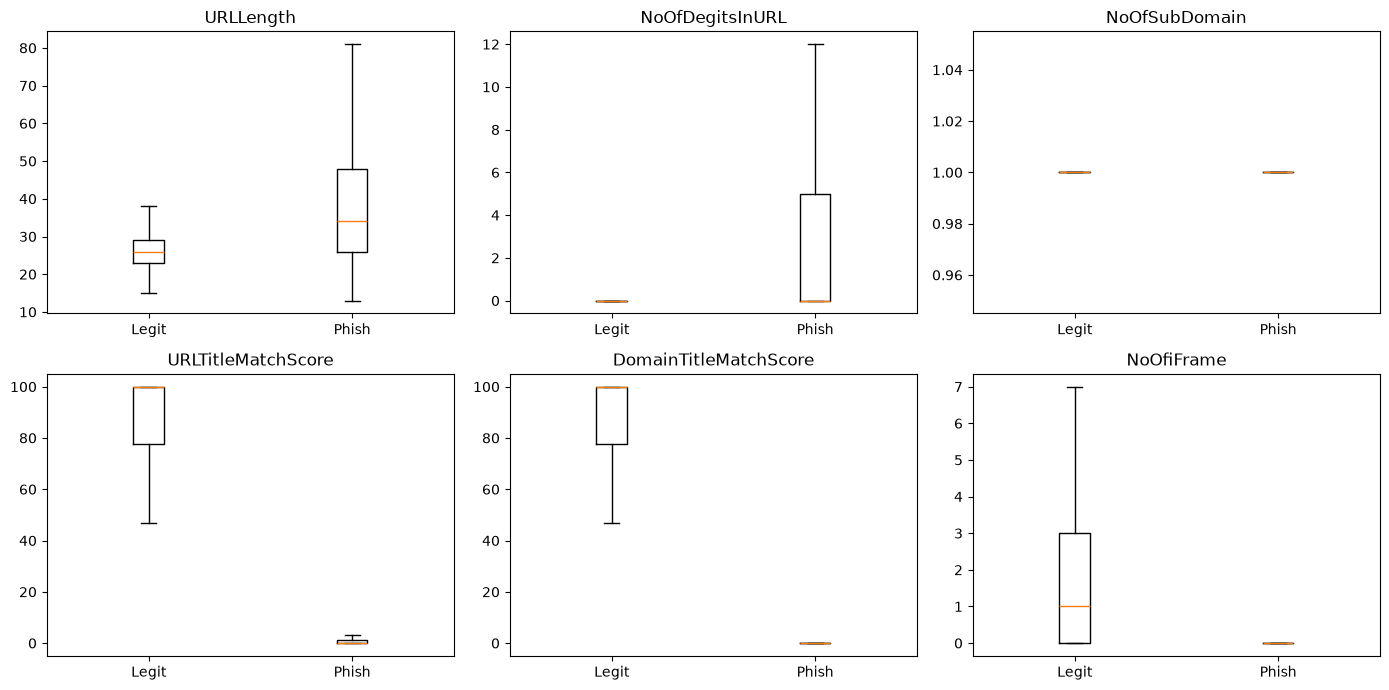


Rata-rata fitur kunci per kelas:
kelas                  Legitimate  Phishing
URLLength                   26.23     45.70
NoOfDegitsInURL              0.05      4.32
NoOfSubDomain                1.16      1.17
URLTitleMatchScore          75.27     21.24
DomainTitleMatchScore       75.27     16.60
NoOfiFrame                   2.71      0.08

Pasangan fitur |korelasi|>0.85: [('URLLength', 'NoOfLettersInURL', np.float64(0.96)), ('DomainTitleMatchScore', 'URLTitleMatchScore', np.float64(0.96))]


In [4]:
# 2b. EDA LENGKAP — distribusi kelas, statistik deskriptif, sebaran fitur per kelas
print('Ringkasan dataset:')
print(f'  Baris={len(X):,} | Fitur={X.shape[1]} | Missing={int(X.isnull().sum().sum())} '
      f'| Duplikat fitur={X.duplicated().sum():,}')

# 1) Distribusi kelas + heatmap korelasi antar-fitur
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
counts = pd.Series(y).map({0: 'Phishing', 1: 'Legitimate'}).value_counts()
bars = ax[0].bar(counts.index, counts.values, color=['#d9534f', '#5cb85c'])
for b, v in zip(bars, counts.values):
    ax[0].text(b.get_x() + b.get_width()/2, v, f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', va='bottom')
ax[0].set_title('Distribusi Kelas'); ax[0].set_ylabel('jumlah sampel')
sns.heatmap(X.corr(), cmap='coolwarm', center=0, ax=ax[1], cbar_kws={'shrink': .7})
ax[1].set_title('Korelasi antar-fitur (multikolinearitas)')
plt.tight_layout(); plt.show()

# 2) Statistik deskriptif
print('\nStatistik deskriptif fitur:')
print(X.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2).to_string())

# 3) Sebaran fitur kunci per kelas (boxplot)
key_feats = [f for f in ['URLLength', 'NoOfDegitsInURL', 'NoOfSubDomain',
                         'URLTitleMatchScore', 'DomainTitleMatchScore', 'NoOfiFrame']
             if f in X.columns]
if key_feats:
    eda2 = X.copy(); eda2['kelas'] = np.where(y == 0, 'Phishing', 'Legitimate')
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for axx, fcol in zip(axes.ravel(), key_feats):
        dl = eda2.loc[eda2['kelas'] == 'Legitimate', fcol]
        dp = eda2.loc[eda2['kelas'] == 'Phishing', fcol]
        axx.boxplot([dl, dp], showfliers=False)
        axx.set_xticks([1, 2]); axx.set_xticklabels(['Legit', 'Phish']); axx.set_title(fcol)
    for axx in axes.ravel()[len(key_feats):]:
        axx.axis('off')
    plt.tight_layout(); plt.show()
    print('\nRata-rata fitur kunci per kelas:')
    print(eda2.groupby('kelas')[key_feats].mean().round(2).T.to_string())

# 4) Pasangan fitur berkorelasi tinggi (>0.85) -> kandidat redundan
cm_abs = X.corr().abs()
high = [(cm_abs.columns[i], cm_abs.columns[j], round(cm_abs.iloc[i, j], 2))
        for i in range(len(cm_abs)) for j in range(i+1, len(cm_abs)) if cm_abs.iloc[i, j] > 0.85]
print('\nPasangan fitur |korelasi|>0.85:', high if high else '(tidak ada -> relatif independen)')

In [5]:
# 3. SPLIT PER-DOMAIN + cek leakage
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
tr_i, te_i = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[tr_i].reset_index(drop=True), X.iloc[te_i].reset_index(drop=True)
y_train, y_test = y[tr_i], y[te_i]
g_train, g_test = groups[tr_i], groups[te_i]

assert len(set(g_train) & set(g_test)) == 0, 'Domain bocor!'
print(f'Train: {len(X_train):,} ({(y_train==0).mean()*100:.1f}% phishing)')
print(f'Test : {len(X_test):,} ({(y_test==0).mean()*100:.1f}% phishing)')
print(f'Domain unik train={len(set(g_train)):,} | test={len(set(g_test)):,}')

Train: 182,147 (40.7% phishing)
Test : 53,223 (49.7% phishing)
Domain unik train=136,846 | test=34,212


In [6]:
# 4. CEK KESEIMBANGAN KELAS (pakai data TRAIN saja)
vc = pd.Series(y_train).value_counts(normalize=True).rename({0: 'Phishing(0)', 1: 'Legitimate(1)'})
print('Distribusi label (train):')
print(vc.round(4))
imb = vc.max() / vc.min()
print(f'\nRasio imbalance: {imb:.2f}x ->',
      'gunakan F1/Recall sebagai metrik utama' if imb > 1.5 else 'relatif seimbang')

neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)
print(f'scale_pos_weight (neg/pos) = {scale_pos_weight:.3f}')

Distribusi label (train):
Legitimate(1)    0.5934
Phishing(0)      0.4066
Name: proportion, dtype: float64

Rasio imbalance: 1.46x -> relatif seimbang
scale_pos_weight (neg/pos) = 0.685


In [7]:
# 5. SELEKSI FITUR DENGAN RFE (fit di TRAINING saja) — pilih 12 fitur terbaik (URL+HTML stabil)
#    Pakai RFE dengan jumlah fitur DITENTUKAN (target 10-14) supaya model ringkas
#    & tidak kebanyakan fitur. Ubah N_FEATURES bila perlu.
from sklearn.feature_selection import RFE

N_FEATURES = 12                      # target 10-14
rng = np.random.RandomState(RANDOM_STATE)
sel_idx = rng.choice(len(X_train), size=min(100000, len(X_train)), replace=False)
X_sel, y_sel = X_train.iloc[sel_idx], y_train[sel_idx]
print(f'RFE pakai subsample {len(X_sel):,} baris training, target {N_FEATURES} fitur.')

rfe_est = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                            eval_metric='logloss', importance_type='gain',
                            random_state=RANDOM_STATE, n_jobs=-1)
rfe = RFE(estimator=rfe_est, n_features_to_select=N_FEATURES, step=1)
t0 = time.time()
rfe.fit(X_sel, y_sel)
print(f'RFE selesai {time.time()-t0:.1f}s | jumlah fitur terpilih = {rfe.n_features_}')

SELECTED_FEATURES = [f for f, k in zip(FEATURES, rfe.support_) if k]
dropped = [f for f, k in zip(FEATURES, rfe.support_) if not k]
print(f'\nTERPILIH ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}')
print(f'\nDIBUANG  ({len(dropped)}): {dropped}')

rank_df = pd.DataFrame({'fitur': FEATURES, 'rank': rfe.ranking_}).sort_values('rank')
print('\nRanking RFE (1 = terpilih, makin besar makin awal dibuang):')
print(rank_df.to_string(index=False))

X_train = X_train[SELECTED_FEATURES]
X_test  = X_test[SELECTED_FEATURES]
print(f'\nDimensi setelah seleksi -> X_train {X_train.shape}')

RFE pakai subsample 100,000 baris training, target 12 fitur.
RFE selesai 13.2s | jumlah fitur terpilih = 12

TERPILIH (12): ['NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'DomainTitleMatchScore', 'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSubmitButton', 'HasHiddenFields', 'HasCopyrightInfo']

DIBUANG  (23): ['URLLength', 'DomainLength', 'IsDomainIP', 'CharContinuationRate', 'TLDLength', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'LetterRatioInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'SpacialCharRatioInURL', 'HasTitle', 'URLTitleMatchScore', 'Robots', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasPasswordField', 'Bank', 'Pay', 'Crypto']

Ranking RFE (1 = terpilih, makin besar makin awal dibuang):
                     fitur  rank
             NoOfSubDomain     1
          NoOfLettersInURL     1
           NoOfDegitsInURL     1
           HasSubmitButton     1
     DomainTi

In [8]:
# 6. HYPERPARAMETER TUNING domain-aware (GroupKFold) — skor F1 phishing
param_dist = {
    'n_estimators': [300, 400, 500, 600],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'max_depth': [4, 5, 6, 7, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 3.0],
}
base = xgb.XGBClassifier(eval_metric='logloss', tree_method='hist',
                         scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=1)
gkf = GroupKFold(n_splits=3)
search = RandomizedSearchCV(base, param_dist, n_iter=20, scoring=f1_phish,
                            cv=list(gkf.split(X_train, y_train, groups=g_train)),
                            n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
t0 = time.time()
search.fit(X_train, y_train)
best_params = search.best_params_
print(f'\nTuning {time.time()-t0:.1f}s | F1 phishing CV = {search.best_score_:.4f}')
print('Best params:', best_params)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Tuning 55.4s | F1 phishing CV = 0.9941
Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [9]:
# 7. TRAINING MODEL FINAL (best_params + early stopping)
gss_v = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
a_i, v_i = next(gss_v.split(X_train, y_train, groups=g_train))
X_a, X_v = X_train.iloc[a_i], X_train.iloc[v_i]
y_a, y_v = y_train[a_i], y_train[v_i]

final_params = dict(n_estimators=600, learning_rate=0.05, max_depth=6, min_child_weight=5,
                    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0, gamma=0.1)
final_params.update(best_params)
final_params['n_estimators'] = max(final_params.get('n_estimators', 600), 1000)

model = xgb.XGBClassifier(**final_params, scale_pos_weight=scale_pos_weight,
                          eval_metric='logloss', early_stopping_rounds=50,
                          tree_method='hist', importance_type='gain',
                          random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.time()
model.fit(X_a, y_a, eval_set=[(X_v, y_v)], verbose=False)
best_it = getattr(model, 'best_iteration', None)
print(f'Training {time.time()-t0:.1f}s | best_iteration={best_it}')
print(f'Akurasi train={accuracy_score(y_a, model.predict(X_a))*100:.2f}% | test={accuracy_score(y_test, model.predict(X_test))*100:.2f}%')

Training 1.9s | best_iteration=517
Akurasi train=99.77% | test=99.76%


In [10]:
# 8. OPTIMASI THRESHOLD (di validasi, bukan test)
vp = model.predict_proba(X_v)[:, 0]
vy = (y_v == 0).astype(int)
pc, rc, th = precision_recall_curve(vy, vp)
f1c = 2*pc*rc/(pc+rc+1e-9)
bi = int(np.argmax(f1c[:-1]))
BEST_THRESHOLD = float(th[bi])
print(f'Threshold optimal = {BEST_THRESHOLD:.3f} (F1 phishing val={f1c[bi]:.4f})')

def predict_thr(proba_phish, t=BEST_THRESHOLD):
    return np.where(proba_phish >= t, 0, 1)

Threshold optimal = 0.565 (F1 phishing val=0.9970)


Threshold=0.565

               precision    recall  f1-score   support

  Phishing(0)       1.00      1.00      1.00     26452
Legitimate(1)       1.00      1.00      1.00     26771

     accuracy                           1.00     53223
    macro avg       1.00      1.00      1.00     53223
 weighted avg       1.00      1.00      1.00     53223



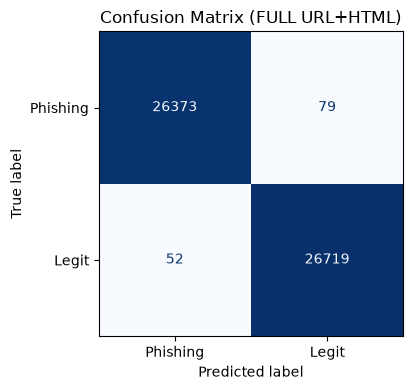

[Phishing] P=0.9980 R=0.9970 F1=0.9975
ROC-AUC = 1.0000


In [11]:
# 9. EVALUASI (threshold optimal)
yp_phish = model.predict_proba(X_test)[:, 0]
y_pred = predict_thr(yp_phish)
print(f'Threshold={BEST_THRESHOLD:.3f}\n')
print(classification_report(y_test, y_pred, target_names=['Phishing(0)', 'Legitimate(1)']))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Phishing', 'Legit']).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (FULL URL+HTML)'); plt.tight_layout(); plt.show()

print(f'[Phishing] P={precision_score(y_test, y_pred, pos_label=0):.4f} '
      f'R={recall_score(y_test, y_pred, pos_label=0):.4f} '
      f'F1={f1_score(y_test, y_pred, pos_label=0):.4f}')
yi = (y_test == 0).astype(int)
fpr, tpr, _ = roc_curve(yi, yp_phish)
print(f'ROC-AUC = {auc(fpr, tpr):.4f}')

F1 phishing asli = 0.9953 | F1 label-acak = 0.1378 | p-value = 0.0323
=> Model SIGNIFIKAN (bukan kebetulan)

Top 10 fitur (gain):
HasCopyrightInfo              0.5378
HasDescription                0.1641
IsHTTPS                       0.1242
NoOfOtherSpecialCharsInURL    0.0492
HasSubmitButton               0.0289
HasFavicon                    0.0270
HasHiddenFields               0.0189
NoOfSubDomain                 0.0164
NoOfDegitsInURL               0.0109
DomainTitleMatchScore         0.0105
dtype: float32


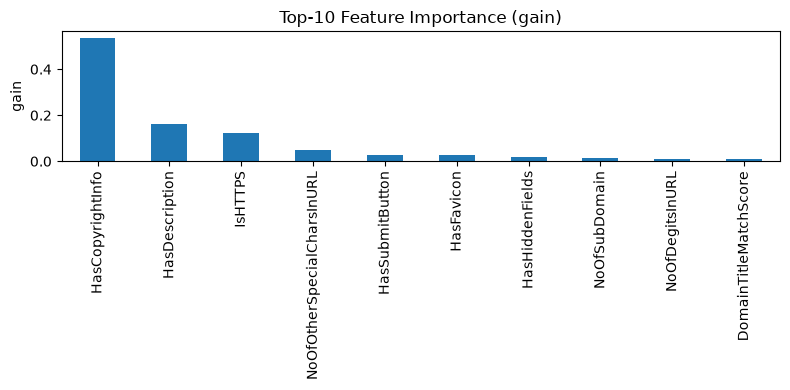


Dominasi fitur teratas 'HasCopyrightInfo' = 53.8% dari total gain -> sehat, tidak ada dominasi ekstrem


In [12]:
# 10. PERMUTATION TEST + FEATURE IMPORTANCE (konsisten dgn skripsi.ipynb)
from sklearn.model_selection import permutation_test_score

# (a) Permutation test: pastikan performa BUKAN kebetulan (subset + CV kecil agar cepat).
sub = np.random.RandomState(RANDOM_STATE).choice(len(X_train), size=min(20000, len(X_train)), replace=False)
n_trees = (best_it + 1) if best_it else 300
perm_model = xgb.XGBClassifier(n_estimators=n_trees, learning_rate=0.05, max_depth=5,
                               subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
                               tree_method='hist', eval_metric='logloss',
                               random_state=RANDOM_STATE, n_jobs=-1)
score, perm_scores, pvalue = permutation_test_score(
    perm_model, X_train.iloc[sub], y_train[sub],
    scoring=f1_phish, cv=3, n_permutations=30, n_jobs=-1, random_state=RANDOM_STATE)
print(f'F1 phishing asli = {score:.4f} | F1 label-acak = {perm_scores.mean():.4f} | p-value = {pvalue:.4f}')
print('=> Model SIGNIFIKAN (bukan kebetulan)' if pvalue < 0.05 else '=> Model TIDAK signifikan')

# (b) Feature importance (gain) — hanya fitur terpilih.
imp = pd.Series(model.feature_importances_, index=list(X_train.columns)).sort_values(ascending=False)
print('\nTop 10 fitur (gain):')
print(imp.head(10).round(4))
plt.figure(figsize=(8, 4))
imp.head(10).plot(kind='bar')
plt.title('Top-10 Feature Importance (gain)'); plt.ylabel('gain'); plt.tight_layout(); plt.show()

top_share = imp.iloc[0] / imp.sum() * 100
print(f"\nDominasi fitur teratas '{imp.index[0]}' = {top_share:.1f}% dari total gain ->",
      'WASPADA, cek leakage' if top_share > 60 else 'sehat, tidak ada dominasi ekstrem')

SHAP>0 -> dorong ke legitimate; SHAP<0 -> dorong ke phishing



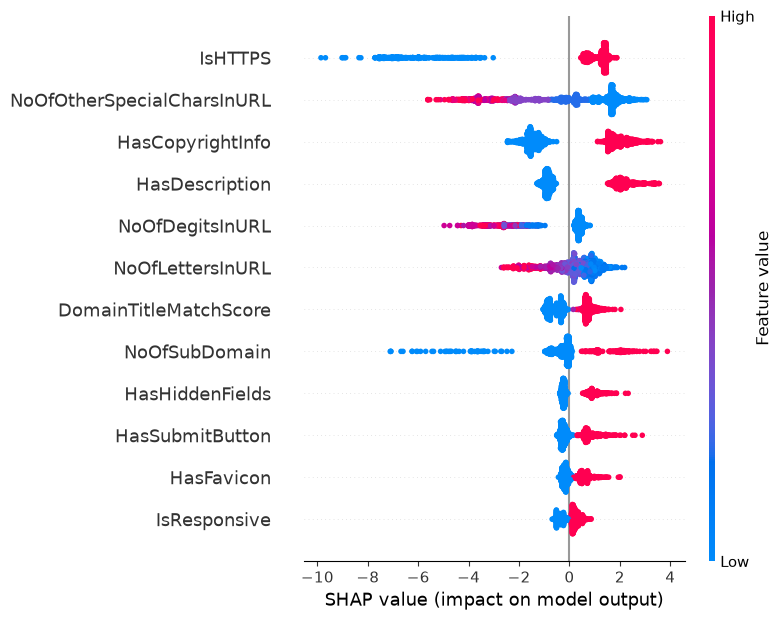

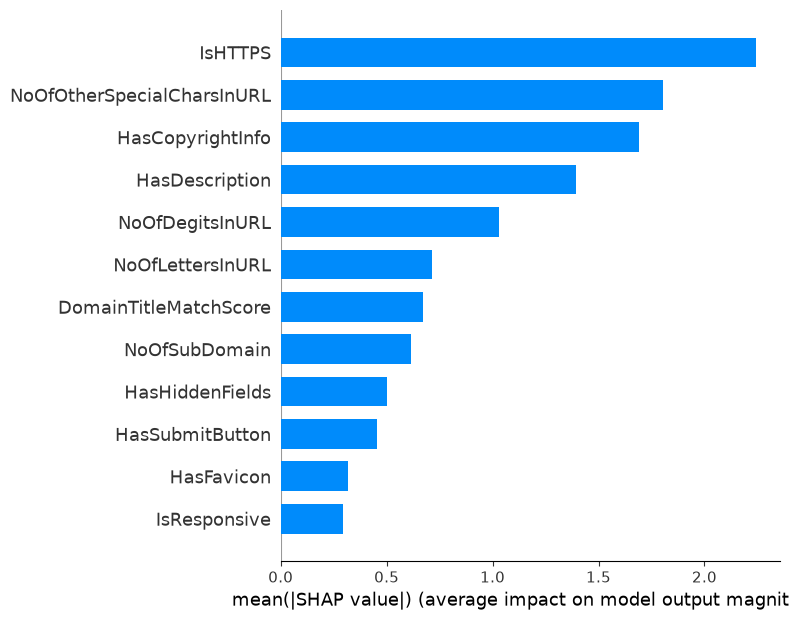

In [13]:
# 11. SHAP (explainability) — perlu: pip install shap
try:
    import shap
except ImportError:
    print('pip install shap dulu'); shap = None
if shap is not None:
    samp = X_test.sample(min(1500, len(X_test)), random_state=RANDOM_STATE)
    expl = shap.TreeExplainer(model)
    sv = expl.shap_values(samp)
    print('SHAP>0 -> dorong ke legitimate; SHAP<0 -> dorong ke phishing\n')
    shap.summary_plot(sv, samp, show=True)
    shap.summary_plot(sv, samp, plot_type='bar', show=True)

In [14]:
# 12. CONTOH PREDIKSI DI TEST SET (model dataset tidak bisa diuji URL live tanpa fitur konten)
#     Kita tampilkan beberapa sampel test beserta P(phishing) sebagai bukti kerja model.
rng2 = np.random.RandomState(RANDOM_STATE)
show = rng2.choice(len(X_test), size=min(12, len(X_test)), replace=False)
proba = model.predict_proba(X_test.iloc[show])[:, 0]
tab = pd.DataFrame({
    'aktual': np.where(y_test[show] == 0, 'phishing', 'legit'),
    'prediksi': np.where(proba >= BEST_THRESHOLD, 'phishing', 'legit'),
    'P(phishing)': np.round(proba, 3),
})
tab['match'] = np.where(tab['aktual'] == tab['prediksi'], 'OK', 'XX')
print(tab.to_string(index=False))

print('\n' + '='*70)
print('CATATAN DEPLOYMENT:')
print('Model ini butuh fitur konten dataset (NoOfCSS, Robots, IsResponsive, dll) yang')
print('TIDAK bisa dihitung backend dari URL secara live -> maka model ini untuk')
print('EVALUASI/PEMBANDING skripsi. Backend produksi tetap pakai model URL-only')
print('(skripsi.ipynb -> model_xgboost_url.pkl) yang konsisten train<->serve.')
print('='*70)

  aktual prediksi  P(phishing) match
   legit    legit        0.003    OK
phishing phishing        1.000    OK
   legit    legit        0.000    OK
phishing phishing        1.000    OK
phishing phishing        1.000    OK
   legit    legit        0.003    OK
   legit    legit        0.000    OK
   legit    legit        0.002    OK
   legit    legit        0.000    OK
phishing phishing        1.000    OK
phishing phishing        1.000    OK
   legit    legit        0.000    OK

CATATAN DEPLOYMENT:
Model ini butuh fitur konten dataset (NoOfCSS, Robots, IsResponsive, dll) yang
TIDAK bisa dihitung backend dari URL secara live -> maka model ini untuk
EVALUASI/PEMBANDING skripsi. Backend produksi tetap pakai model URL-only
(skripsi.ipynb -> model_xgboost_url.pkl) yang konsisten train<->serve.


In [15]:
# 13. EXPORT MODEL DATASET (nama file terpisah -> TIDAK dipakai backend produksi)
joblib.dump(model, 'model_xgboost_dataset.pkl')
joblib.dump(SELECTED_FEATURES, 'dataset_feature_schema.pkl')
joblib.dump(BEST_THRESHOLD, 'dataset_threshold.pkl')
print('Tersimpan: model_xgboost_dataset.pkl, dataset_feature_schema.pkl, dataset_threshold.pkl')
print(f'Fitur terpilih ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}')
print('\nModel ini = PEMBANDING AKADEMIK (URL+HTML dataset). Untuk bab hasil/perbandingan.')
print('Backend produksi tetap memakai model URL-only dari skripsi.ipynb.')

Tersimpan: model_xgboost_dataset.pkl, dataset_feature_schema.pkl, dataset_threshold.pkl
Fitur terpilih (12): ['NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'DomainTitleMatchScore', 'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSubmitButton', 'HasHiddenFields', 'HasCopyrightInfo']

Model ini = PEMBANDING AKADEMIK (URL+HTML dataset). Untuk bab hasil/perbandingan.
Backend produksi tetap memakai model URL-only dari skripsi.ipynb.


In [16]:
# 14. UJI: 3 LEGIT vs 3 PHISHING (diambil dari DATASET test set)
#     Model dataset butuh fitur konten -> tidak bisa URL live. Jadi kita ambil
#     contoh nyata dari TEST SET (data yang TIDAK dipakai latih) + URL aslinya,
#     lalu tampilkan prediksi model.
test_pos = pd.DataFrame({'pos': te_i, 'label': y[te_i]})
phish_pos = test_pos[test_pos['label'] == 0]['pos'].head(3).tolist()   # 0 = phishing
legit_pos = test_pos[test_pos['label'] == 1]['pos'].head(3).tolist()   # 1 = legit
pick = phish_pos + legit_pos

Xpick = X.iloc[pick][SELECTED_FEATURES]
proba = model.predict_proba(Xpick)[:, 0]    # P(phishing)

rows = []
for pos_i, p in zip(pick, proba):
    url = str(df['URL'].iloc[pos_i])
    actual = 'phishing' if df['label'].iloc[pos_i] == 0 else 'legitimate'
    pred = 'phishing' if p >= BEST_THRESHOLD else 'legitimate'
    rows.append({
        'url': (url[:55] + '...') if len(url) > 55 else url,
        'aktual': actual,
        'prediksi': pred,
        'P(phishing)': round(float(p), 3),
        'match': 'OK' if actual == pred else 'XX',
    })

hasil = pd.DataFrame(rows)
print(f"Threshold = {BEST_THRESHOLD:.3f}  (P(phishing) >= threshold -> phishing)\n")
print(hasil.to_string(index=False))
print(f"\nBenar {(hasil['match']=='OK').sum()}/{len(hasil)} contoh.")
print("\nCatatan: ini contoh nyata dari TEST SET (bukan data latih). Model dataset")
print("tidak bisa diuji dengan mengetik URL baru karena perlu fitur konten halaman.")

Threshold = 0.565  (P(phishing) >= threshold -> phishing)

                               url     aktual   prediksi  P(phishing) match
       http://www.f0519141.xsph.ru   phishing   phishing          1.0    OK
          http://www.shprakserf.gq   phishing   phishing          1.0    OK
 http://www.kuradox92.lima-city.de   phishing   phishing          1.0    OK
               https://www.aap.org legitimate legitimate          0.0    OK
https://www.religionenlibertad.com legitimate legitimate          0.0    OK
       https://www.bulgariaski.com legitimate legitimate          0.0    OK

Benar 6/6 contoh.

Catatan: ini contoh nyata dari TEST SET (bukan data latih). Model dataset
tidak bisa diuji dengan mengetik URL baru karena perlu fitur konten halaman.


In [17]:
# 15. UJI LIVE: SCRAPE URL -> hitung fitur terpilih -> prediksi (model FULL URL+HTML)
# reload modul supaya selalu pakai versi terbaru phiusiil_live.py (hindari cache kernel)
import importlib, phiusiil_live
importlib.reload(phiusiil_live)
from phiusiil_live import extract_features_live, PHIUSIIL_FEATURES

missing = [f for f in SELECTED_FEATURES if f not in PHIUSIIL_FEATURES]
if missing:
    print(f"[!] Fitur terpilih yg TIDAK bisa dihitung live: {missing}\n")

cek_urls = [
    ("https://www.google.com",  "legitimate"),
    ("https://www.youtube.com", "legitimate"),
    ("https://github.com",      "legitimate"),
    ("https://www.wikipedia.org", "legitimate"),
    ("http://login-verify-account.security-update.tk/webscr?cmd=update", "phishing"),
]

rows = []
for u, exp in cek_urls:
    f, why = extract_features_live(u, timeout=10, return_reason=True)   # tampilkan alasan
    if f is None:
        rows.append({"url": u[:46], "harapan": exp, "prediksi": f"GAGAL: {why}",
                     "P(phishing)": None, "match": "-"})
        continue
    Xr = pd.DataFrame([f])[SELECTED_FEATURES]
    p = float(model.predict_proba(Xr)[0][0])      # P(phishing) = kelas 0
    pred = "phishing" if p >= BEST_THRESHOLD else "legitimate"
    rows.append({"url": u[:46], "harapan": exp, "prediksi": pred,
                 "P(phishing)": round(p, 3), "match": "OK" if pred == exp else "XX"})

print(f"Threshold = {BEST_THRESHOLD:.3f}  (P(phishing) >= threshold -> phishing)\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\n[!] 'GAGAL: <alasan>' = scrape gagal (di backend -> fallback URL-only).")
print("    Kalau google/youtube tetap 'phishing' walau scrape sukses -> itu krn situs JS-berat:")
print("    HTML mentahnya kosong (konten dimuat via JS) -> sisa train-serving skew.")

Threshold = 0.565  (P(phishing) >= threshold -> phishing)

                                           url    harapan                                      prediksi  P(phishing) match
                        https://www.google.com legitimate                                    legitimate        0.001    OK
                       https://www.youtube.com legitimate                                    legitimate        0.000    OK
                            https://github.com legitimate                                      phishing        0.826    XX
                     https://www.wikipedia.org legitimate                                    legitimate        0.000    OK
http://login-verify-account.security-update.tk   phishing GAGAL: connection_error (situs mati/diblokir)          NaN     -

[!] 'GAGAL: <alasan>' = scrape gagal (di backend -> fallback URL-only).
    Kalau google/youtube tetap 'phishing' walau scrape sukses -> itu krn situs JS-berat:
    HTML mentahnya kosong (konten dimuat 

In [18]:
# 16. BEDAH 1 URL — kenapa diprediksi phishing/legit? (nilai fitur + kontribusi SHAP)
import importlib, phiusiil_live
importlib.reload(phiusiil_live)
from phiusiil_live import extract_features_live

URL_BEDAH = "https://www.amazon.com"     # <-- ganti URL sesukamu

f, why = extract_features_live(URL_BEDAH, timeout=10, return_reason=True)
if f is None:
    print(f"Scrape GAGAL: {why}  -> di backend akan masuk fallback URL-only.")
else:
    Xr = pd.DataFrame([f])[SELECTED_FEATURES]
    p = float(model.predict_proba(Xr)[0][0])     # P(phishing) = kelas 0
    pred = "phishing" if p >= BEST_THRESHOLD else "legitimate"
    print(f"URL         : {URL_BEDAH}")
    print(f"P(phishing) = {p:.3f}  (threshold {BEST_THRESHOLD:.3f})  ->  {pred}\n")

    try:
        import shap
        sv = shap.TreeExplainer(model).shap_values(Xr)
        if isinstance(sv, list):       # versi shap lama -> list per kelas
            sv = sv[-1]
        sv_row = np.array(sv)[0]       # SHAP menjelaskan skor kelas 1 = LEGIT
        contrib = pd.DataFrame({
            "fitur": SELECTED_FEATURES,
            "nilai_fitur": Xr.iloc[0].values,
            "SHAP": np.round(sv_row, 4),     # (+) dorong ke legit, (-) dorong ke phishing
        }).sort_values("SHAP")
        print(">> Fitur yang paling MENDORONG ke PHISHING (SHAP paling negatif):")
        print(contrib.head(6).to_string(index=False))
        print("\n>> Fitur yang paling MENDORONG ke LEGITIMATE (SHAP paling positif):")
        print(contrib.tail(6).iloc[::-1].to_string(index=False))
        print("\nCatatan: situs login/belanja (amazon, paypal, bank) sering punya fitur")
        print("seperti HasPasswordField/Pay/form eksternal yang juga ciri phishing -> false positive.")
    except ImportError:
        print("SHAP belum terpasang (pip install shap). Nilai fitur:")
        print(Xr.T.rename(columns={0: 'nilai'}).to_string())

URL         : https://www.amazon.com
P(phishing) = 0.325  (threshold 0.565)  ->  legitimate

>> Fitur yang paling MENDORONG ke PHISHING (SHAP paling negatif):
                fitur  nilai_fitur    SHAP
     HasCopyrightInfo          0.0 -2.2202
       HasDescription          0.0 -1.2522
      HasSubmitButton          0.0 -0.3534
      HasHiddenFields          0.0 -0.3174
DomainTitleMatchScore          0.0 -0.3028
        NoOfSubDomain          1.0 -0.2780

>> Fitur yang paling MENDORONG ke LEGITIMATE (SHAP paling positif):
                     fitur  nilai_fitur    SHAP
NoOfOtherSpecialCharsInURL          0.0  2.9282
                   IsHTTPS          1.0  1.3976
              IsResponsive          1.0  0.8549
           NoOfDegitsInURL          0.0  0.4028
          NoOfLettersInURL         17.0  0.0555
                HasFavicon          0.0 -0.1355

Catatan: situs login/belanja (amazon, paypal, bank) sering punya fitur
seperti HasPasswordField/Pay/form eksternal yang juga ciri phis